# Customer Experience (CX) Analysis of Support Tickets
## 1. Introduction
Customer support tickets provide valuable insights into customer pain points, service quality, and operational performance. Understanding recurring issues, customer segments, and ticket priorities helps businesses improve customer experience (CX), reduce friction points, and allocate support resources effectively.

This project analyses 10,000 customer support tickets to identify:

Most common customer issues
Ticket distribution across customer plans
Priority trends
Frequently occurring support topics
Customer experience improvement opportunities

In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [13]:
# import CSV
df = pd.read_csv("ticketsupport.csv")

In [14]:
print(df.shape)

(10000, 6)


In [15]:
df.head()

,Index,Ticket ID,Customer Plan,Ticket Subject,Ticket Text,Priority Hint
0,1,BGLXVMkiDh,Enterprise,Webhook failed during enrichment,I need help with LinkedIn URLs because we foun...,Urgent
1,2,IlatxTSdB1,Pro,Invoice has extra seats,"After checking a canceled add-on, we saw that ...",Medium
2,3,ZxsWg7bx1e,Enterprise,CSV columns shifted after upload,"While preparing a lead file for a deadline, we...",High
3,4,p8lxBSAAKC,Enterprise,Large export is slow,"Our team is working on a 200k-row collection, ...",Urgent
4,5,LGGSmTywc6,Free,Save AI prompts for the team,A teammate checked cleaning prompts and found ...,Low


## 2. Data Quality Checks

In [9]:
# Dataset Overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Index           10000 non-null  int64 
 1   Ticket ID       10000 non-null  object
 2   Customer Plan   10000 non-null  object
 3   Ticket Subject  10000 non-null  object
 4   Ticket Text     10000 non-null  object
 5   Priority Hint   10000 non-null  object
dtypes: int64(1), object(5)
memory usage: 468.9+ KB
None


In [6]:
df.describe(include="object")

,Ticket ID,Customer Plan,Ticket Subject,Ticket Text,Priority Hint
count,10000,10000,10000,10000,10000
unique,10000,5,24,9999,4
top,BGLXVMkiDh,Starter,Export has been running too long,"Our team is working on smart quotes, and we fo...",High
freq,1,2052,460,2,2571


In [10]:
# Missing Values
df.isnull().sum()

Index             0
Ticket ID         0
Customer Plan     0
Ticket Subject    0
Ticket Text       0
Priority Hint     0
dtype: int64

In [11]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

## 3. Customer Plan Analysis

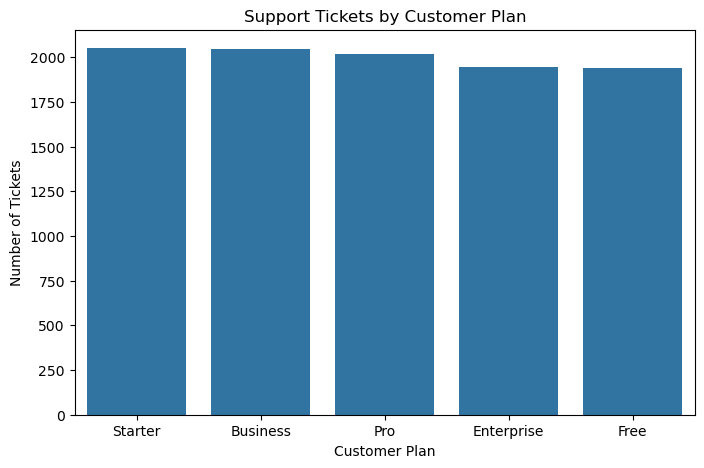

In [18]:
plan_counts = df["Customer Plan"].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(
    x=plan_counts.index, 
    y=plan_counts.values 
)
plt.title("Support Tickets by Customer Plan")
plt.xlabel("Customer Plan")
plt.ylabel("Number of Tickets")
plt.show()

**Insights**

- Support ticket volumes are relatively consistent across all subscription tiers, ranging from approximately 1,950 to 2,050 tickets.
- Starter and Business plans generate the highest number of support tickets, while Free and Enterprise plans generate slightly fewer requests.
- The small variation suggests that support demand is not concentrated within a single customer segment.
- This may indicate that customer issues are experienced similarly across plans rather than being driven by a specific subscription tier.
- Since no plan shows disproportionately high ticket volumes, improvement efforts should focus on common customer issues affecting all users rather than targeting a single plan.

**Consumer Insights Interpretation**

Customer support demand is broadly distributed across all customer plans, suggesting that customer challenges are shared across the user base. This indicates that product usability, onboarding, or support processes may have a greater impact on ticket creation than subscription tier alone.

## 4. Ticket Priority Analysis

In [19]:
priority_counts = df["Priority Hint"].value_counts()

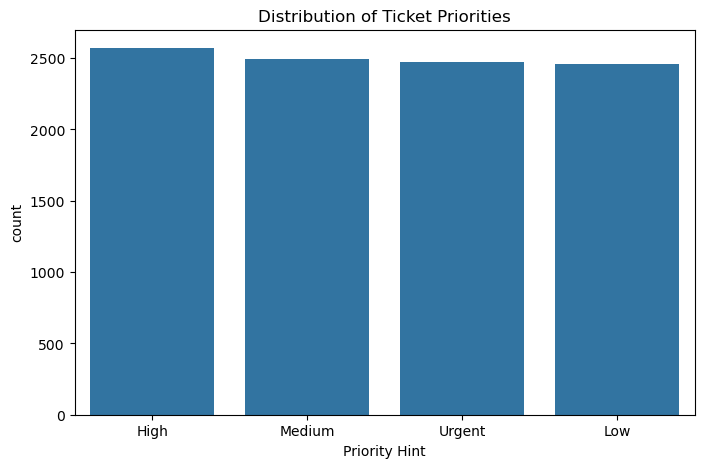

In [22]:
plt.figure(figsize=(8,5)) 
sns.countplot( 
    data=df, 
    x="Priority Hint", 
    order=priority_counts.index 
)
plt.title("Distribution of Ticket Priorities") 
plt.show()

**Insight:**
- Ticket priorities are almost evenly distributed across all severity levels, with counts ranging from approximately 2,450 to 2,600 tickets.
- High-priority tickets account for the largest share of support requests, although the difference compared to other priority levels is minimal.
- The relatively balanced distribution suggests that customer issues vary in severity and are not concentrated within a single priority category.
- The high volume of High and Urgent tickets indicates that customers frequently encounter issues requiring prompt attention, which may place pressure on support resources and service level agreements (SLAs).
- Since critical tickets are nearly as common as lower-priority requests, support teams may need efficient triage processes to ensure urgent cases are resolved promptly.
Monitoring priority levels helps support teams manage SLAs.

**Consumer Insights Interpretation**

The even distribution of ticket priorities suggests that customers experience a broad range of issues, from minor concerns to critical service disruptions. The slightly higher volume of High-priority tickets indicates recurring pain points that may significantly impact the customer experience and warrant further investigation.

## 5. Customer Plan vs Priority

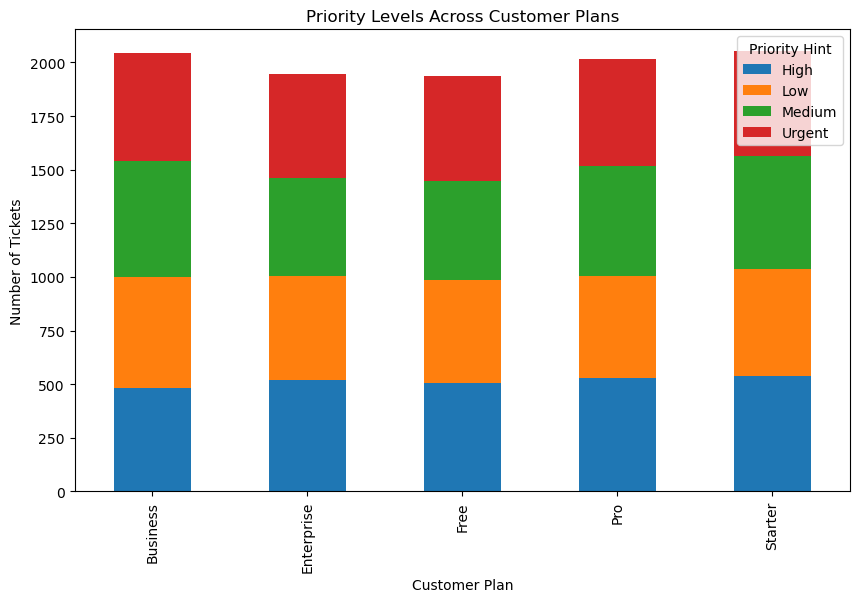

In [26]:
cross_tab = pd.crosstab(
    df["Customer Plan"],
    df["Priority Hint"]
)
cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6) 
)
plt.title("Priority Levels Across Customer Plans") 
plt.ylabel("Number of Tickets") 
plt.show()

**Insight**
Ticket priorities are distributed relatively evenly across all customer plans, indicating that issue severity is consistent regardless of subscription tier.
Starter and Business plans generate slightly more total tickets than other plans; however, the differences are marginal.
High and Urgent tickets are present across all customer segments, suggesting that critical customer issues affect users regardless of their subscription level.
No single customer plan appears to disproportionately contribute to severe support requests.
This suggests that customer pain points may stem from common product or service issues rather than problems unique to a particular plan.

**Consumer Insights Interpretation**

The similar priority distributions across customer plans indicate that support challenges are experienced consistently across the customer base. Critical issues are not isolated to premium or free users, suggesting that improvements to core product functionality and support processes could benefit all customer segments.

## 6. Top Support Issues

In [27]:
top_subjects = df["Ticket Subject"].value_counts().head(10)

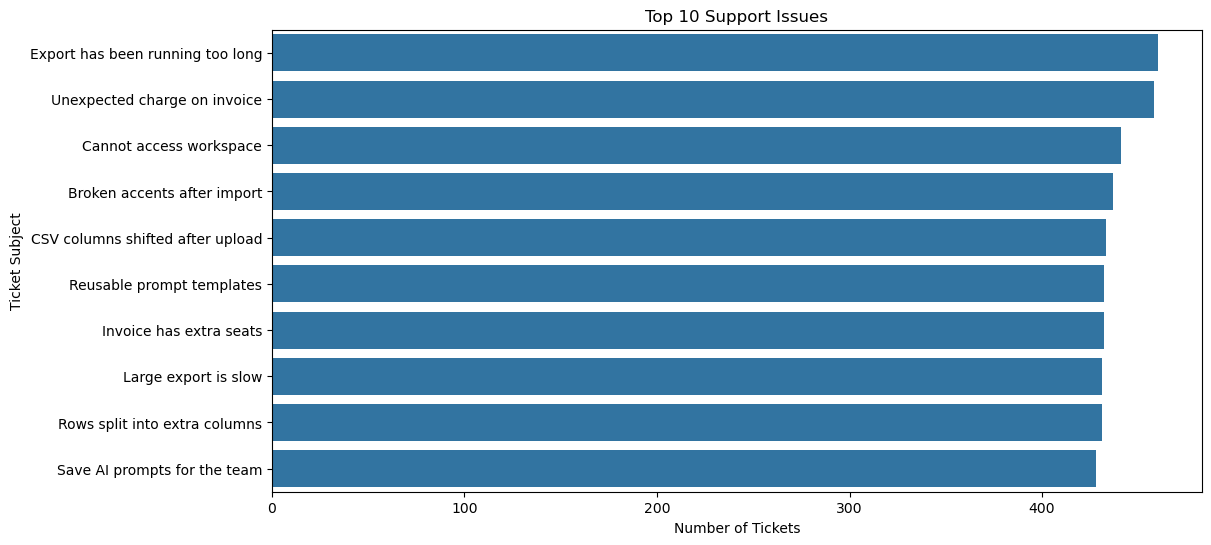

In [28]:
plt.figure(figsize=(12,6))
sns.barplot( 
    x=top_subjects.values, 
    y=top_subjects.index 
)
plt.title("Top 10 Support Issues")
plt.xlabel("Number of Tickets")
plt.show()

Insight
The most frequently reported issues relate to data exports, billing, workspace access, and data imports, indicating that customers primarily experience challenges with core platform functionality.
Export-related problems ("Export has been running too long" and "Large export is slow") are among the most common support requests, suggesting performance bottlenecks during data extraction processes.
Billing concerns, including unexpected invoice charges and additional seat charges, are also major drivers of support demand and may negatively impact customer trust if not addressed promptly.
Access-related issues such as workspace login and account import problems indicate friction during onboarding, authentication, or account management processes.
The relatively small differences in ticket volumes across the top issues suggest that customer pain points are distributed across several functional areas rather than being dominated by a single problem.

Consumer Insights Interpretation

Customers rely heavily on exporting data, managing billing, and accessing collaborative workspaces. Friction in these core workflows appears to be a key driver of support interactions and may directly affect customer satisfaction and product adoption.

## 7. Pareto Analysis

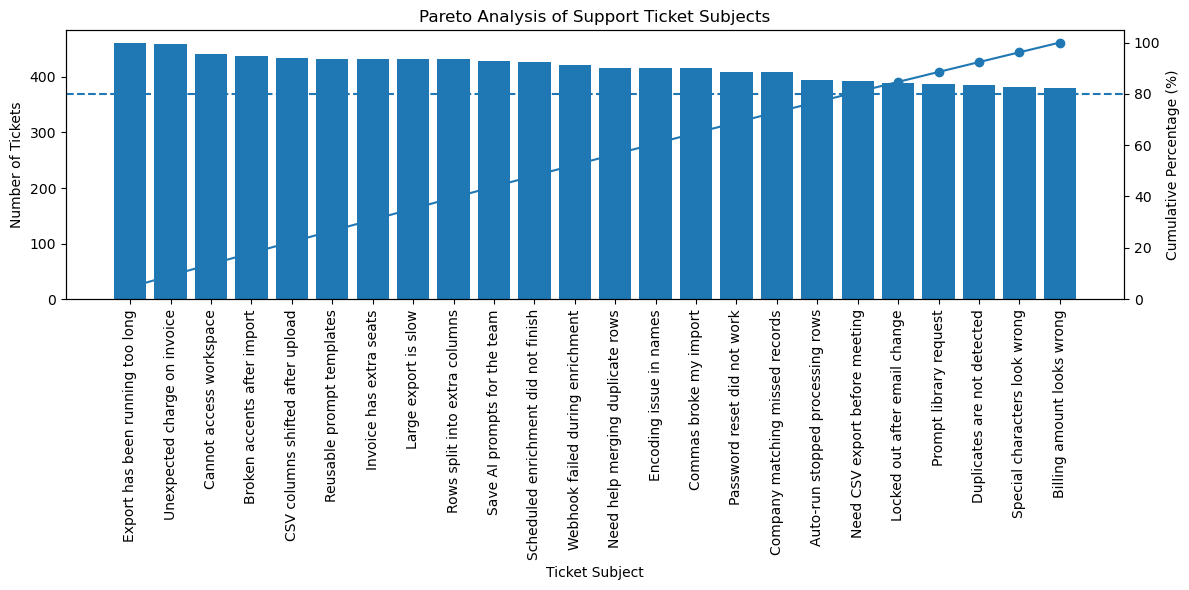

In [39]:
# Count ticket subjects

pareto = (
    df["Ticket Subject"]
    .value_counts()
    .reset_index()
)

pareto.columns = ["Ticket Subject", "Count"]

# Calculate cumulative percentage

pareto["Cumulative Percentage"] = (
    pareto["Count"].cumsum()
    / pareto["Count"].sum()
) * 100

# Create Pareto Chart

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart
ax1.bar(
    pareto["Ticket Subject"],
    pareto["Count"]
)

ax1.set_xlabel("Ticket Subject")
ax1.set_ylabel("Number of Tickets")

plt.xticks(rotation=90)

# Line chart for cumulative %
ax2 = ax1.twinx()

ax2.plot(
    pareto["Ticket Subject"],
    pareto["Cumulative Percentage"],
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage (%)")

# 80% reference line
ax2.axhline(
    y=80,
    linestyle="--"
)

plt.title("Pareto Analysis of Support Ticket Subjects")

plt.tight_layout()
plt.show()

Insight
Support requests are spread across a wide range of ticket categories, with no single issue overwhelmingly dominating ticket volume.
The cumulative percentage line rises gradually, indicating that customer support demand is driven by numerous recurring issues rather than a small number of isolated problems.
Approximately 80% of support tickets are generated by a broad group of ticket categories rather than only a few subjects.
This suggests that customer experience challenges are distributed across multiple product features, including exports, billing, imports, workspace access, and integrations.
The organisation may need a broad product improvement strategy rather than focusing on a single high-impact issue.
Consumer Insights Interpretation

Customer frustrations appear to stem from multiple areas of the product ecosystem. Rather than one critical defect driving support demand, customers experience a variety of operational, usability, and workflow-related issues.

## 8. High-Priority Issues

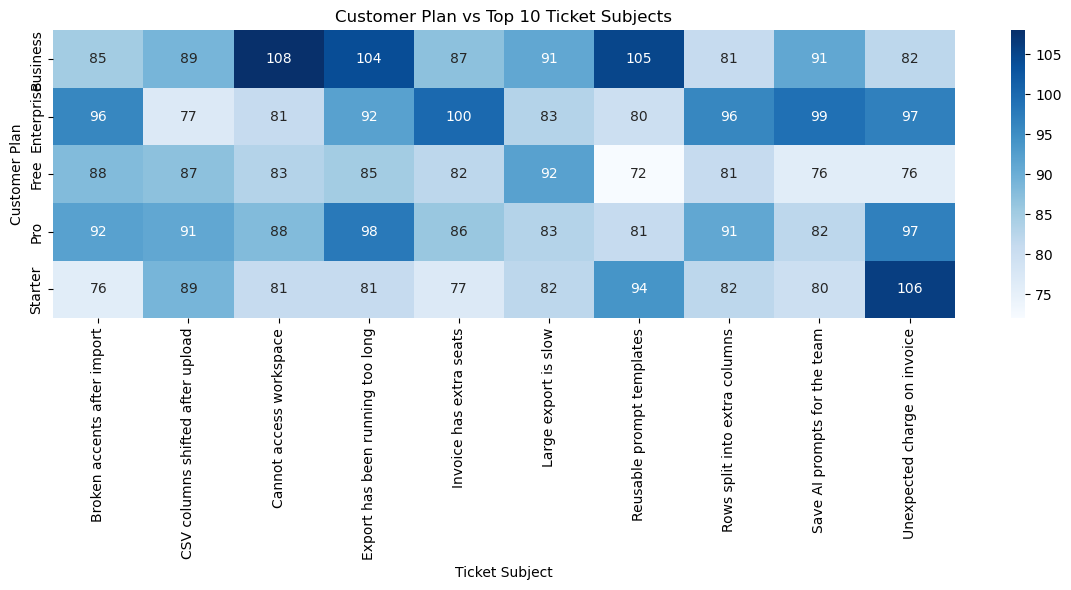

In [40]:
# Top 10 ticket subjects

top_subjects = (
    df["Ticket Subject"]
    .value_counts()
    .head(10)
    .index
)

# Filter data

filtered_df = df[
    df["Ticket Subject"].isin(top_subjects)
]

# Crosstab

plan_subject = pd.crosstab(
    filtered_df["Customer Plan"],
    filtered_df["Ticket Subject"]
)

# Plot

plt.figure(figsize=(12,6))

sns.heatmap(
    plan_subject,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Customer Plan vs Top 10 Ticket Subjects")

plt.tight_layout()
plt.show()

Insight
The heatmap answers ""What problems do different customer groups experience?". Ticket subjects are relatively evenly distributed across customer plans, suggesting that most customer issues are experienced across the entire user base rather than being isolated to a specific subscription tier.
Business customers report the highest volume of workspace access issues (108 tickets) and export performance issues (104 tickets), indicating greater reliance on collaboration and data management features.
Starter customers generate the highest number of billing-related tickets, particularly unexpected invoice charges (106 tickets), which may suggest pricing confusion or onboarding challenges among newer customers.
Enterprise customers report comparatively more issues related to invoicing, account management, and team collaboration features, which may reflect the complexity of managing larger organisations.
Free users generally report lower ticket volumes across most categories, although export and data-upload issues remain common concerns.

Consumer Insights Interpretation

While customer pain points are broadly shared across all subscription plans, certain issues appear more prominent within specific segments. Business users are more concerned with operational workflows and workspace accessibility, whereas Starter users are more likely to raise billing-related concerns. This suggests that customer needs vary slightly by subscription tier despite the overall similarity in ticket patterns.

## 9. Key Insights & Recommendations

## Key Insights

### 1. Support demand is evenly distributed across customer plans

Ticket volumes were relatively similar across Starter, Business, Pro, Enterprise, and Free plans, suggesting that support needs are shared across the customer base rather than concentrated within a specific subscription tier.

### 2. Customer issues vary in severity but remain balanced

High, Medium, Low, and Urgent tickets occurred at similar frequencies, indicating that customers experience a broad range of issues. The presence of a substantial number of High and Urgent tickets highlights the importance of maintaining effective ticket prioritisation and service-level management.

### 3. Export, billing, and workspace access issues are the most common customer pain points

The most frequent support requests related to export performance, unexpected invoice charges, workspace access, and data import errors. These issues represent core product workflows and have a direct impact on customer productivity and satisfaction.

### 4. Customer support demand is driven by multiple recurring issues

The Pareto Analysis showed that support requests are distributed across numerous ticket categories rather than being dominated by a single issue. This suggests that customer experience challenges stem from several product and operational areas.

### 5. Different customer segments experience different challenges

Business customers reported more workspace access and export-related issues, while Starter customers generated more billing-related enquiries. This indicates opportunities for segment-specific support resources and customer education initiatives.

---

## Recommendations

### 1. Improve product performance for high-frequency issues

Prioritise enhancements to export functionality, workspace access, and data import processes to reduce recurring support requests and improve customer experience.

### 2. Increase billing transparency

Review invoicing workflows, pricing communication, and account management processes to minimise billing-related enquiries and improve customer trust.

### 3. Develop targeted self-service resources

Create help-centre articles, FAQs, onboarding guides, and troubleshooting resources focused on the most common ticket categories to reduce support volume and empower customers to resolve issues independently.

### 4. Implement customer-segment-specific support strategies

Provide tailored guidance for different customer plans. For example, Starter customers may benefit from billing and onboarding support, while Business customers may require additional assistance with collaboration and data management features.

### 5. Monitor high-priority issues proactively

Establish regular monitoring of High and Urgent ticket categories to identify emerging customer pain points and ensure critical issues are resolved efficiently.

---

## Conclusions

This analysis explored customer support ticket data to identify recurring customer issues, ticket severity patterns, and support demand across subscription plans. The findings reveal that support requests are broadly distributed across customer segments and priority levels, with export performance, billing concerns, and workspace access emerging as the most common customer pain points.

While no single customer segment or issue category overwhelmingly drives support demand, several recurring themes contribute to customer frustration and operational workload. By improving core product functionality, enhancing self-service support resources, and adopting targeted customer support strategies, organisations can reduce ticket volumes, improve service efficiency, and deliver a better overall customer experience.
